## **Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## **Setup**

In [ ]:
BASE_DIR  = '/content/drive/MyDrive/Colab Datasets'   # sesuaikan path Drive Anda
SPLIT_DIR = f'{BASE_DIR}/Split Data'

FINAL_CSV = f'{BASE_DIR}/combined_dataset_final.csv'

os.makedirs(SPLIT_DIR, exist_ok=True)
print('Directories ready.')

Directories ready.


## **Load Dataset**

In [ ]:
df = pd.read_csv(FINAL_CSV)

print(f'Total rows : {len(df):,}')
print(f'Columns    : {list(df.columns)}')
print()
print(df.dtypes)
print()
df.head()

Total rows : 40,000
Columns    : ['id', 'text', 'label', 'language', 'has_slang', 'has_abbrev', 'source']

id             int64
text          object
label          int64
language      object
has_slang      int64
has_abbrev     int64
source        object
dtype: object



,id,text,label,language,has_slang,has_abbrev,source
0,1,orang kristen kristen itu sering melecehkan si...,1,mixed,0,1,generated
1,2,user it kill to go to the white house and eat ...,0,en,0,0,tonneau_english
2,3,"golongan kafir itu fr fr gak ada manfaatnya, s...",1,mixed,0,1,generated
3,4,digrebek sama jokowi yang disalahkan demokrasi...,1,id,1,0,tonneau_indonesian
4,5,etnis tionghoa tuh emang maunya nguasain ekono...,1,mixed,0,0,generated


## **Check Column & Distribution**

In [ ]:
# Sanity checks sebelum split
assert df['label'].isin([0, 1]).all(),               'label harus 0 atau 1'
assert df['language'].isin(['id', 'en', 'mixed']).all(), 'language tidak valid'
assert df['text'].notna().all(),                     'ada text kosong — bersihkan dulu'
assert df['has_slang'].isin([0, 1]).all(),           'has_slang harus 0 atau 1'
assert df['has_abbrev'].isin([0, 1]).all(),          'has_abbrev harus 0 atau 1'

print('Distribusi label:')
print(df['label'].value_counts(normalize=True).rename({0:'non-hate', 1:'hate'}))
print()
print('Distribusi language:')
print(df['language'].value_counts(normalize=True))
print()
print('Cross-tab label × language:')
print(pd.crosstab(df['language'], df['label'],
                  colnames=['label'], rownames=['language'],
                  margins=True, normalize='index').round(3))

Distribusi label:
label
hate        0.5
non-hate    0.5
Name: proportion, dtype: float64

Distribusi language:
language
mixed    0.40515
en       0.30000
id       0.29485
Name: proportion, dtype: float64

Cross-tab label × language:
label         0      1
language              
en        0.500  0.500
id        0.509  0.491
mixed     0.494  0.506
All       0.500  0.500


## **Generate Stratification Key**

In [ ]:
df['strat_key'] = (
    df['language'].astype(str) + '_' +
    df['label'].astype(str)    + '_' +
    df['has_slang'].astype(str) + '_' +
    df['has_abbrev'].astype(str)
)

print('Distribusi strat_key:')
print(df['strat_key'].value_counts().sort_index())
print(f'\nJumlah strata unik: {df["strat_key"].nunique()}')

# Validasi: strata dengan terlalu sedikit sampel bisa menyebabkan error
min_strata = df['strat_key'].value_counts().min()
print(f'Strata terkecil   : {min_strata} sampel')
if min_strata < 3:
    print('  ⚠️  Strata < 3 sampel: pertimbangkan gabungkan strata kecil')
else:
    print('  ✅ Semua strata cukup besar untuk 3-way split')

Distribusi strat_key:
strat_key
en_0_0_0       5028
en_0_0_1        754
en_0_1_0        172
en_0_1_1         46
en_1_0_0       5079
en_1_0_1        693
en_1_1_0        174
en_1_1_1         54
id_0_0_0       2335
id_0_0_1       1712
id_0_1_0        753
id_0_1_1       1200
id_1_0_0       1702
id_1_0_1       1821
id_1_1_0        828
id_1_1_1       1443
mixed_0_0_0    1163
mixed_0_0_1     553
mixed_0_1_0    2338
mixed_0_1_1    3946
mixed_1_0_0    2897
mixed_1_0_1    3655
mixed_1_1_0     376
mixed_1_1_1    1278
Name: count, dtype: int64

Jumlah strata unik: 24
Strata terkecil   : 46 sampel
  ✅ Semua strata cukup besar untuk 3-way split


## **Split Data**

In [ ]:
RANDOM_STATE = 42
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, 'Rasio harus berjumlah 1.0'

df_trainval, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    stratify=df['strat_key'],
    random_state=RANDOM_STATE
)

val_size_from_trainval = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_size_from_trainval,
    stratify=df_trainval['strat_key'],
    random_state=RANDOM_STATE
)

for split in [df_train, df_val, df_test]:
    split.drop(columns=['strat_key'], inplace=True, errors='ignore')

total = len(df_train) + len(df_val) + len(df_test)
print(f'Train : {len(df_train):,} rows ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val):,} rows ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test):,} rows ({len(df_test)/len(df)*100:.1f}%)')
print(f'Total : {total:,} (harus sama dengan {len(df):,})')
assert total == len(df), 'PERINGATAN: jumlah baris tidak konsisten!'

Train : 28,000 rows (70.0%)
Val   : 6,000 rows (15.0%)
Test  : 6,000 rows (15.0%)
Total : 40,000 (harus sama dengan 40,000)


## **Verification of Split Distribution**

In [ ]:
def check_distribution(name: str, split: pd.DataFrame, reference: pd.DataFrame,
                        drift_threshold: float = 0.05) -> None:
    print(f'\n{"="*60}')
    print(f'Split: {name}  ({len(split):,} rows)')
    print('-'*60)
    for col in ['label', 'language', 'has_slang', 'has_abbrev']:
        ref_dist  = reference[col].value_counts(normalize=True).sort_index()
        spl_dist  = split[col].value_counts(normalize=True).sort_index()
        diff      = (spl_dist - ref_dist).abs()
        max_drift = diff.max()
        status    = '✅ OK' if max_drift <= drift_threshold else '⚠️  DRIFT > 5%!'
        print(f'  {col:<12} — max drift: {max_drift:.4f}  {status}')

for name, split in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    check_distribution(name, split, df)


Split: TRAIN  (28,000 rows)
------------------------------------------------------------
  label        — max drift: 0.0000  ✅ OK
  language     — max drift: 0.0000  ✅ OK
  has_slang    — max drift: 0.0001  ✅ OK
  has_abbrev   — max drift: 0.0000  ✅ OK

Split: VAL  (6,000 rows)
------------------------------------------------------------
  label        — max drift: 0.0000  ✅ OK
  language     — max drift: 0.0000  ✅ OK
  has_slang    — max drift: 0.0003  ✅ OK
  has_abbrev   — max drift: 0.0001  ✅ OK

Split: TEST  (6,000 rows)
------------------------------------------------------------
  label        — max drift: 0.0002  ✅ OK
  language     — max drift: 0.0002  ✅ OK
  has_slang    — max drift: 0.0000  ✅ OK
  has_abbrev   — max drift: 0.0000  ✅ OK


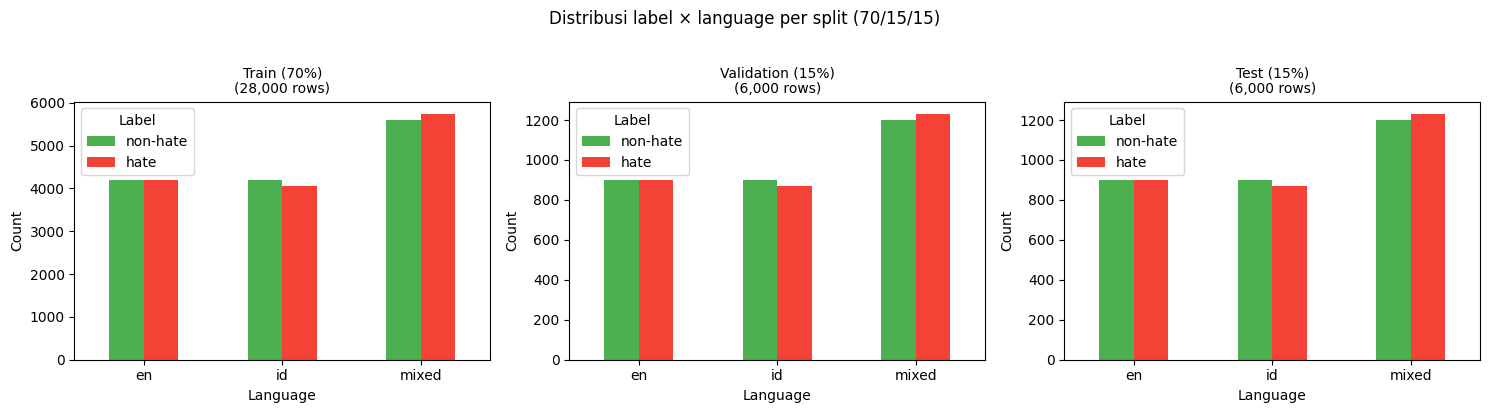

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = {'Train (70%)': df_train, 'Validation (15%)': df_val, 'Test (15%)': df_test}
colors = {0: '#4CAF50', 1: '#F44336'}

for ax, (name, split) in zip(axes, splits.items()):
    counts = split.groupby(['language', 'label']).size().unstack(fill_value=0)
    counts.columns = [f'label={c}' for c in counts.columns]
    counts.plot(kind='bar', ax=ax, color=[colors[0], colors[1]], rot=0, edgecolor='none')
    ax.set_title(f'{name}\n({len(split):,} rows)', fontsize=10)
    ax.set_xlabel('Language')
    ax.set_ylabel('Count')
    ax.legend(labels=['non-hate', 'hate'], title='Label')

plt.suptitle('Distribusi label × language per split (70/15/15)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{SPLIT_DIR}/split_distribution_701515.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## **Save**

In [ ]:
df_train.to_csv(f'{SPLIT_DIR}/train.csv', index=False)
df_val.to_csv(f'{SPLIT_DIR}/val.csv',   index=False)
df_test.to_csv(f'{SPLIT_DIR}/test.csv', index=False)

print('Files saved:')
for fname in ['train.csv', 'val.csv', 'test.csv']:
    path = f'{SPLIT_DIR}/{fname}'
    size = os.path.getsize(path) / 1024 / 1024
    rows = pd.read_csv(path).shape[0]
    print(f'  {fname:<12} {rows:>7,} rows   {size:.2f} MB')

Files saved:
  train.csv     28,000 rows   3.91 MB
  val.csv        6,000 rows   0.83 MB
  test.csv       6,000 rows   0.84 MB


## **Summary**

In [ ]:
summary = pd.DataFrame({
    'Partisi'  : ['Training set', 'Validation set', 'Test set', 'Total'],
    'Jumlah'   : [len(df_train), len(df_val), len(df_test),
                  len(df_train)+len(df_val)+len(df_test)],
    'Proporsi' : [
        f'{len(df_train)/len(df)*100:.1f}%',
        f'{len(df_val)/len(df)*100:.1f}%',
        f'{len(df_test)/len(df)*100:.1f}%',
        '100%'
    ],
    'Kegunaan' : [
        'Update parameter model + bangun TF-IDF lexicon',
        'Optuna tuning + threshold ROC + early stopping',
        'Evaluasi akhir (tidak disentuh selama development)',
        ''
    ]
})
print('Tabel partisi data (untuk Bab 3):')
print(summary.to_string(index=False))

Tabel partisi data (untuk Bab 3):
       Partisi  Jumlah Proporsi                                           Kegunaan
  Training set   28000    70.0%     Update parameter model + bangun TF-IDF lexicon
Validation set    6000    15.0%     Optuna tuning + threshold ROC + early stopping
      Test set    6000    15.0% Evaluasi akhir (tidak disentuh selama development)
         Total   40000     100%                                                   


## **Final Statistic per Split**

In [ ]:
def split_stats(name: str, split: pd.DataFrame) -> None:
    print(f'\n── {name} ({len(split):,} baris) ──')
    print(split.groupby(['language', 'label']).size().unstack(fill_value=0)
             .rename(columns={0: 'non-hate', 1: 'hate'})
             .assign(total=lambda x: x.sum(axis=1))
             .assign(pct_hate=lambda x: (x['hate'] / x['total'] * 100).round(1)))

for n, s in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    split_stats(n, s)

print('\n✅ Notebook 01 selesai. Lanjut ke Notebook 02 (TF-IDF + BIO labeling).')


── TRAIN (28,000 baris) ──
label     non-hate  hate  total  pct_hate
language                                 
en            4200  4200   8400      50.0
id            4200  4057   8257      49.1
mixed         5599  5744  11343      50.6

── VAL (6,000 baris) ──
label     non-hate  hate  total  pct_hate
language                                 
en             900   900   1800      50.0
id             900   869   1769      49.1
mixed         1200  1231   2431      50.6

── TEST (6,000 baris) ──
label     non-hate  hate  total  pct_hate
language                                 
en             900   900   1800      50.0
id             900   868   1768      49.1
mixed         1201  1231   2432      50.6

✅ Notebook 01 selesai. Lanjut ke Notebook 02 (TF-IDF + BIO labeling).
